# Description

```markdown
Problem   : Classification
Resolve   : Learning : Deep Learning
Field     : 
Algorithm : Neural Network
Network   : CNN
Action    : Relu | Softmax
Loss      : categorical_crossentropy
Optimizer : adam
Train     : Supervised
Input     : Feature | Label
Output    : Multi-Class
Dataset   : Structured : mnist
Tag       : Automatic differentiation | GradientTape
```

# General

Import

In [1]:
import time
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
import keras as ks

/Volumes/data/documents/ai_document/.myenv3/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# Data

Dataset : Read

In [2]:
(x_train, y_train), (x_test, y_test) = ks.datasets.mnist.load_data()

Data : Normalization

In [3]:
x_train = (x_train / 255).reshape((-1, 28, 28, 1))
x_test = (x_test / 255).reshape((-1, 28, 28, 1))

Label : Encoding : One-Hot

In [4]:
y_test = ks.utils.to_categorical(y_test, 10)
y_train = ks.utils.to_categorical(y_train, 10)

Display

In [5]:
print("x_train : {}".format(x_train.shape))
print("x_test  : {}".format(x_test.shape))
print("y_train : {}".format(y_train.shape))
print("y_test  : {}".format(y_test.shape))

x_train : (60000, 28, 28, 1)
x_test  : (10000, 28, 28, 1)
y_train : (60000, 10)
y_test  : (10000, 10)


# Model

Variable

In [6]:
EPOCHS = 5
BATCH_SIZE = 128
BATCH_PER_EPOCH_TRAIN = int(len(x_train)/BATCH_SIZE)
BATCH_PER_EPOCH_TEST = int(len(x_test)/BATCH_SIZE)

Optimizers

In [7]:
# lr_schedule = ks.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate=0.01,
#     decay_steps=EPOCHS,
#     decay_rate=0.01,
#     staircase=False
# )

# opt_sgd = ks.optimizers.SGD(learning_rate=lr_schedule)
# opt_adam = ks.optimizers.Adam(learning_rate=lr_schedule)
opt_adam = ks.optimizers.Adam(learning_rate=0.01/EPOCHS)

Architecture

In [8]:
mdl = ks.models.Sequential()

mdl.add(ks.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
mdl.add(ks.layers.Conv2D(64, (3, 3), activation="relu"))
mdl.add(ks.layers.MaxPool2D(pool_size=(2, 2))) 
mdl.add(ks.layers.Dropout(0.25))
mdl.add(ks.layers.Flatten())
mdl.add(ks.layers.Dense(128, activation="relu"))
mdl.add(ks.layers.Dense(32, activation="relu"))
mdl.add(ks.layers.Dropout(0.5))
mdl.add(ks.layers.Dense(10, activation="softmax"))

/Volumes/data/documents/ai_document/.myenv3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Train

step_on_epoch

In [ ]:
def step_on_epoch():
    step_loss = []
    for i in range(0, BATCH_PER_EPOCH_TRAIN):
        start = i * BATCH_SIZE
        end = start + BATCH_SIZE
        with tf.GradientTape() as tape:
            p = mdl(x_train[start:end])
            model_loss = ks.losses.categorical_crossentropy(y_train[start:end], p)
        model_gradients = tape.gradient(model_loss, mdl.trainable_variables)
        opt_adam.apply_gradients(zip(model_gradients, mdl.trainable_variables))
        step_loss.append(model_loss)
    return np.mean(step_loss)

Action

In [10]:
train_loss = []
for epoch in range(EPOCHS):
    epochStart = time.time()
    out_loss = step_on_epoch()
    train_loss.append(out_loss)
    epochEnd = time.time()
    elapsed = (epochEnd - epochStart)
    print("epoch: {}, loss:{}, took {:.4}".format(epoch, out_loss, elapsed))

epoch: 0, loss:0.16681607067584991, took 21.34
epoch: 1, loss:0.041145678609609604, took 21.08
epoch: 2, loss:0.024595845490694046, took 20.88
epoch: 3, loss:0.01689087599515915, took 20.8
epoch: 4, loss:0.01546337828040123, took 21.25


# Evaluation

Accuracy

In [11]:
mdl.compile(optimizer=opt_adam, loss="categorical_crossentropy", metrics=['accuracy'])
accuracy = mdl.evaluate(x_test, y_test, verbose=0)[1]
print(accuracy)

0.9828000068664551


Loss

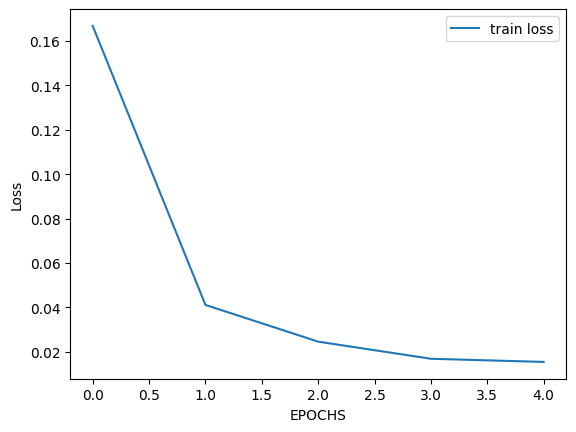

In [12]:
plt.plot(range(EPOCHS), train_loss, label="train loss")
plt.legend()
plt.xlabel('EPOCHS') 
plt.ylabel('Loss')
plt.show()

# Test

In [14]:
def perform_validation():
    val_loss = []
    for i in range(0, BATCH_PER_EPOCH_TEST):
        start = i* BATCH_SIZE
        end = start + BATCH_SIZE
        y_pred = mdl(x_test[start:end])
        loss_on_test_data = ks.losses.categorical_crossentropy(y_test[start:end], y_pred)
        val_loss.append(loss_on_test_data)

    return np.mean(val_loss)

perform_validation()

np.float32(0.060798522)